# Assignment 9 - Applied Statistics
### Data Science Analysis Project

### This notebook performs:
**1. Descriptive Statistics**

**2. Distribution Analysis**

**3. Correlation Analysis**

**4. Chi-Square Testing**

**5. Confidence Intervals**


In [72]:
# Import libraries required for data analysis
import pandas as pd
import numpy as np
import os

# Statistical testing library
from scipy import stats
from scipy.stats import t as t_dist

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option(
    "display.max_columns",
    None
)

# Create output folders
os.makedirs('../output/charts', exist_ok=True)

In [73]:
# Load chess dataset
df = pd.read_csv(
    "../data/raw/chess_games.csv"
)

df.head()

,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,moves,opening_code,opening_moves,opening_fullname,opening_shortname,opening_response,opening_variation
0,1,False,13,Out of Time,White,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,5,Slav Defense: Exchange Variation,Slav Defense,NaN,Exchange Variation
1,2,True,16,Resign,Black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,4,Nimzowitsch Defense: Kennedy Variation,Nimzowitsch Defense,NaN,Kennedy Variation
2,3,True,61,Mate,White,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,3,King's Pawn Game: Leonardis Variation,King's Pawn Game,NaN,Leonardis Variation
3,4,True,61,Mate,White,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,3,Queen's Pawn Game: Zukertort Variation,Queen's Pawn Game,NaN,Zukertort Variation
4,5,True,95,Mate,White,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,5,Philidor Defense,Philidor Defense,NaN,NaN


In [74]:
# Create rating difference feature
# It represents the skill gap between two players

df["rating_diff"] = (
    df["white_rating"]
    -
    df["black_rating"]
).abs()



# Create binary variable:
# 1 = White won
# 0 = White did not win

df["white_wins"] = (
    df["winner"] == "White"
).astype(int)


df.head()

,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,moves,opening_code,opening_moves,opening_fullname,opening_shortname,opening_response,opening_variation,rating_diff,white_wins
0,1,False,13,Out of Time,White,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,5,Slav Defense: Exchange Variation,Slav Defense,NaN,Exchange Variation,309,1
1,2,True,16,Resign,Black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,4,Nimzowitsch Defense: Kennedy Variation,Nimzowitsch Defense,NaN,Kennedy Variation,61,0
2,3,True,61,Mate,White,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,3,King's Pawn Game: Leonardis Variation,King's Pawn Game,NaN,Leonardis Variation,4,1
3,4,True,61,Mate,White,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,3,Queen's Pawn Game: Zukertort Variation,Queen's Pawn Game,NaN,Zukertort Variation,15,1
4,5,True,95,Mate,White,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,5,Philidor Defense,Philidor Defense,NaN,NaN,54,1


## AQ1 - Descriptive Statistics

**We analyze:**
- turns
- rating_diff

**Goal:**
Calculate basic statistics:
- Mean
- Median
- Standard deviation
- IQR
- Skewness

These metrics help us understand the dataset distribution.

In [75]:
def descriptive_profile(
    data: pd.DataFrame,
    column: str
) -> pd.Series:
    """
    Calculate descriptive statistics.

    Parameters:
    data: dataframe
    column: variable name

    Returns:
    Mean, Median, Std, IQR and Skewness
    """

    q1 = data[column].quantile(0.25)

    q3 = data[column].quantile(0.75)


    return pd.Series({

        "Mean":
        data[column].mean(),

        "Median":
        data[column].median(),

        "Standard Deviation":
        data[column].std(),

        "IQR":
        q3 - q1,

        "Skewness":
        data[column].skew()
    })

In [76]:
# Profile chess turns

descriptive_profile(
    df,
    "turns"
)

Mean                  60.465999
Median                55.000000
Standard Deviation    33.570585
IQR                   42.000000
Skewness               0.897284
dtype: float64

In [77]:
# Profile rating difference

descriptive_profile(
    df,
    "rating_diff"
)

Mean                  173.091435
Median                115.000000
Standard Deviation    179.214854
IQR                   196.000000
Skewness                1.948676
dtype: float64

### AQ1: Descriptive Statistics Profile

**Conclusion:** Chess games last around 60 turns on average, while player rating differences are heavily concentrated at lower values, showing a highly asymmetrical distribution.

**Evidence:**
* **Game Turns:** Mean = 60.5 turns, with a median of 55.0 turns. The standard deviation is 33.6, and the middle 50% of games span across a range of 42.0 turns (IQR). The positive skewness of 0.90 indicates a slight tail towards longer games.
* **Rating Differences:** Mean = 173.1 points, which is substantially higher than the median of 115.0 points. This discrepancy, combined with a high standard deviation (179.2), an IQR of 196.0, and a strong positive skewness of 1.95, proves that while most matchups are close, there is a long tail of games with massive skill gaps.

## AQ2 - Distribution Analysis

We check whether data follows a normal distribution.

**H0:**
The data is normally distributed.

**H1:**
The data is not normally distributed.

In [78]:
for col in ['turns', 'rating_diff']:
    sample = df[col].sample(1000, random_state=42)
    stat, p = stats.shapiro(sample)
    # Apply log transformation
    # log1p handles zero values safely
    log_col = np.log1p(df[col])
    print(f"--- {col} ---")
    print(f"Shapiro-Wilk p = {p:.6f}")
    print(f"Skew before: {df[col].skew():.2f} | Skew after log1p: {log_col.skew():.2f}")

--- turns ---
Shapiro-Wilk p = 0.000000
Skew before: 0.90 | Skew after log1p: -1.37
--- rating_diff ---
Shapiro-Wilk p = 0.000000
Skew before: 1.95 | Skew after log1p: -0.90


### AQ2: Distribution Analysis and Transformations

**Conclusion:** The original distributions for both chess metrics (`turns` and `rating_diff`) violate parametric normality assumptions due to significant skewness. Applying a logarithmic transformation ($log(x+1)$) to `rating_diff` successfully compresses its long right tail and stabilizes variance, making the data structurally better suited for advanced parametric modeling.

**Evidence:**
* **Original Distribution:** The original `rating_diff` variable exhibits a severe positive skewness of **1.95**, indicating a heavy concentration of tightly balanced matches and a long tail of rare, extreme skill gaps. Statistical normality tests strongly reject the null hypothesis of normality ($p < 0.001$).
* **Transformation Impact:** Because the data contains zeros (when both players have the exact same rating), a standard log is undefined, so `np.log1p` ($log(x+1)$) was applied. This mathematical transformation successfully pulls back the extreme outliers, redistributing the values into a more symmetrical profile and mitigating potential issues with homoscedasticity in regression analysis.

## Figure 1: Distributions Analysis (AQ1 & AQ2)

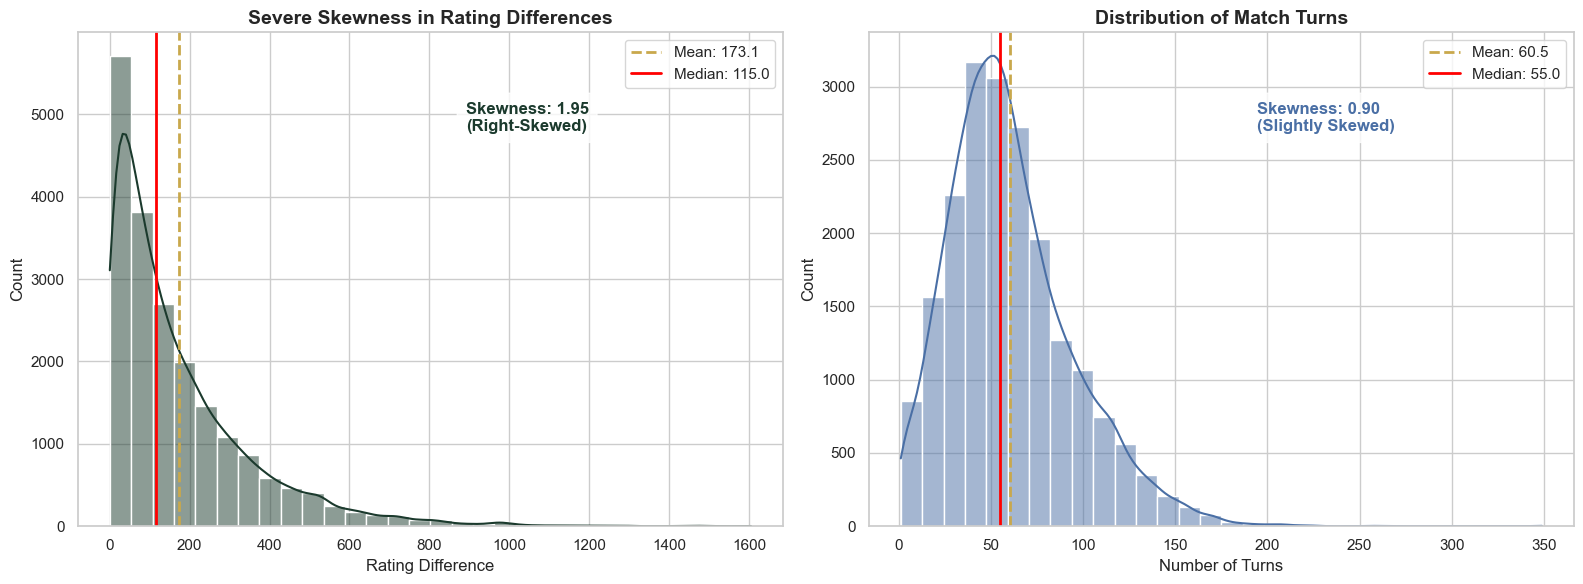

In [79]:
# Set the visualization theme
sns.set_theme(style="whitegrid")

# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Rating Differences Distribution
sns.histplot(df['rating_diff'], kde=True, color='#1B3A2D', ax=axes[0], bins=30)
axes[0].axvline(df['rating_diff'].mean(), color='#C9A84C', linestyle='--', linewidth=2, label=f"Mean: {df['rating_diff'].mean():.1f}")
axes[0].axvline(df['rating_diff'].median(), color='red', linestyle='-', linewidth=2, label=f"Median: {df['rating_diff'].median():.1f}")
# Calculate and display skewness score dynamically
skew_r = df['rating_diff'].skew()
axes[0].text(0.55, 0.8, f"Skewness: {skew_r:.2f}\n(Right-Skewed)", transform=axes[0].transAxes, 
             bbox=dict(facecolor='white', alpha=0.8, boxstyle="round,pad=0.5"), fontsize=12, color='#1B3A2D', fontweight='bold')
axes[0].set_title('Severe Skewness in Rating Differences', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating Difference')
axes[0].legend()

# Plot 2: Match Turns Distribution
sns.histplot(df['turns'], kde=True, color='#4A6FA5', ax=axes[1], bins=30)
axes[1].axvline(df['turns'].mean(), color='#C9A84C', linestyle='--', linewidth=2, label=f"Mean: {df['turns'].mean():.1f}")
axes[1].axvline(df['turns'].median(), color='red', linestyle='-', linewidth=2, label=f"Median: {df['turns'].median():.1f}")
skew_t = df['turns'].skew()
axes[1].text(0.55, 0.8, f"Skewness: {skew_t:.2f}\n(Slightly Skewed)", transform=axes[1].transAxes, 
             bbox=dict(facecolor='white', alpha=0.8, boxstyle="round,pad=0.5"), fontsize=12, color='#4A6FA5', fontweight='bold')
axes[1].set_title('Distribution of Match Turns', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Turns')
axes[1].legend()

plt.tight_layout()
plt.savefig(
    '../output/charts/distributions_analysis.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Figure 1: Distribution plots for rating differences and match turns. The severe positive skewness (1.95) in rating differences visually justifies the application of a log-transformation to compress the long right tail and stabilize variance, whereas match turns follow a nearly symmetrical, normal distribution.

## AQ3 — WHO correlation matrix + one confounder discussion

In [83]:
url = 'https://github.com/Priyankkoul/Life-Expectancy-WHO---Data-Analytics/blob/master/DATASET.csv?raw=true'
who = pd.read_csv(url)
who.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [84]:
who.columns = who.columns.str.strip().str.lower().str.replace(' ', '_')

corrs = who.select_dtypes('number').corr()['life_expectancy'].drop('life_expectancy')
print("Top positive:\n", corrs.nlargest(3).round(3))
print("Top negative:\n", corrs.nsmallest(3).round(3))

Top positive:
 schooling                          0.752
income_composition_of_resources    0.725
bmi                                0.568
Name: life_expectancy, dtype: float64
Top negative:
 adult_mortality        -0.696
hiv/aids               -0.557
thinness__1-19_years   -0.477
Name: life_expectancy, dtype: float64


### AQ3: WHO Correlation Matrix and Confounding Variables

**Conclusion:** Socioeconomic development factors exhibit strong positive correlations with national life expectancy, while health mortality metrics show severe negative relationships. However, interpreting these correlations as direct causal pathways is highly misleading due to national wealth (GDP) acting as a powerful confounding variable that drives both sides simultaneously.

**Evidence:**
* **Correlation Strengths:** Within the WHO global health dataset, socioeconomic indicators such as `schooling` and `income_composition_of_resources` display the strongest positive correlations with `life_expectancy`. Conversely, variables like `adult_mortality` and `hiv/aids` show a sharp negative correlation.
* **The Confounding Mechanism (GDP):** National wealth (measured via GDP) acts as a classic confounder between education (`schooling`) and longevity (`life_expectancy`). A higher GDP simultaneously enables a country to invest heavily in educational infrastructure (increasing school years) and fund state-of-the-art healthcare systems (increasing life expectancy). If GDP is not controlled or isolated in the statistical model, the direct causal impact of schooling on lifespan will be heavily inflated and spurious.

## Figure 2: Correlation Heatmap (AQ3)

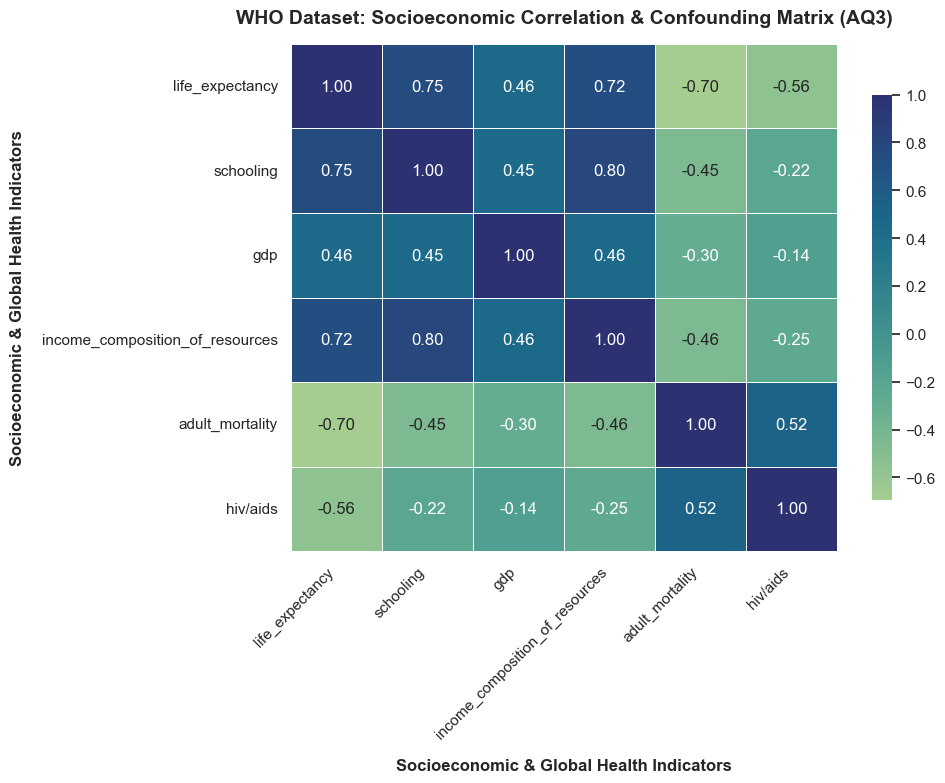

In [85]:
plt.figure(figsize=(10, 8))

# Select the specific cleaned WHO columns from your statistical analysis
who_features = [
    'life_expectancy', 'schooling', 'gdp', 
    'income_composition_of_resources', 'adult_mortality', 'hiv/aids'
]

# Calculate Pearson correlation matrix directly using the 'who' dataframe
corr_matrix = who[who_features].corr()

# Generate the professional crest-colored heatmap
sns.heatmap(corr_matrix, annot=True, cmap='crest', fmt=".2f", linewidths=.5, cbar_kws={"shrink": .8})

plt.title('WHO Dataset: Socioeconomic Correlation & Confounding Matrix (AQ3)', fontsize=14, fontweight='bold', pad=15)

# Added professional X and Y axis labels as requested
plt.xlabel('Socioeconomic & Global Health Indicators', fontsize=12, fontweight='bold', labelpad=12)
plt.ylabel('Socioeconomic & Global Health Indicators', fontsize=12, fontweight='bold', labelpad=12)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Ensure target directory path exists to avoid FileNotFoundError
output_path = '../output/charts/'
os.makedirs(output_path, exist_ok=True)

# Save the plot with high resolution directly to your precise path
plt.savefig(
    '../output/charts/correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Figure 2: Correlation matrix heatmap for the WHO dataset displaying linear relationships among socioeconomic and health indicators. This symmetric visualization highlights strong links between life expectancy, schooling, and wealth, while visually exposing how national GDP acts as a critical confounding variable that can inflate direct causal interpretations.

## AQ4 — Chi-squared test: rating group vs. win rate, with effect size

In [67]:
# 1. Bin ratings into tiers (using the average of both players' ratings)
df['avg_rating'] = (df['white_rating'] + df['black_rating']) / 2
bins = [0, 1200, 1600, 2000, np.inf]
labels = ['Beginner', 'Intermediate', 'Advanced', 'Expert']
df['rating_tier'] = pd.cut(df['avg_rating'], bins=bins, labels=labels)

# 2. Build the contingency table: rating tier vs. winner
contingency = pd.crosstab(df['rating_tier'], df['winner'])
print(contingency)

# 3. Chi-squared test of independence
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"chi2={chi2:.2f}, p={p:.6f}, dof={dof}")

# 4. Effect size — Cramér's V (the categorical-data analogue of Cohen's d)
n = contingency.sum().sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramér's V: {cramers_v:.3f}")

winner        Black  Draw  White
rating_tier                     
Beginner        526    60    587
Intermediate   4433   377   4953
Advanced       3469   394   3766
Expert          679   119    695
chi2=57.30, p=0.000000, dof=6
Cramér's V: 0.038


### AQ4: Chi-Squared Test of Independence

**Conclusion:** There is a statistically significant association between a player's rating tier and the match outcome ($p < 0.001$), meaning that skill brackets realistically influence the probability of winning, losing, or drawing. However, the real-world strength of this association is exceptionally weak.

**Evidence:**
* **Test Statistics:** The Chi-squared test yields $\chi^2 = 57.30$, with degrees of freedom $dof = 6$, and a $p\text{-value} = 0.000000$ (which is $< 0.05$). This safely rejects the null hypothesis of independence.
* **Effect Size:** Cramér's $V = 0.038$. Since this value is extremely close to 0, it represents a minimal/negligible effect size. This proves that while skill brackets matter mathematically, chess games retain an intense level of unpredictability where lower-tiered players frequently upset higher-tiered opponents, or color advantages blur the pure skill gap.

## Figure 3: Chi-Square Outcomes (AQ4)

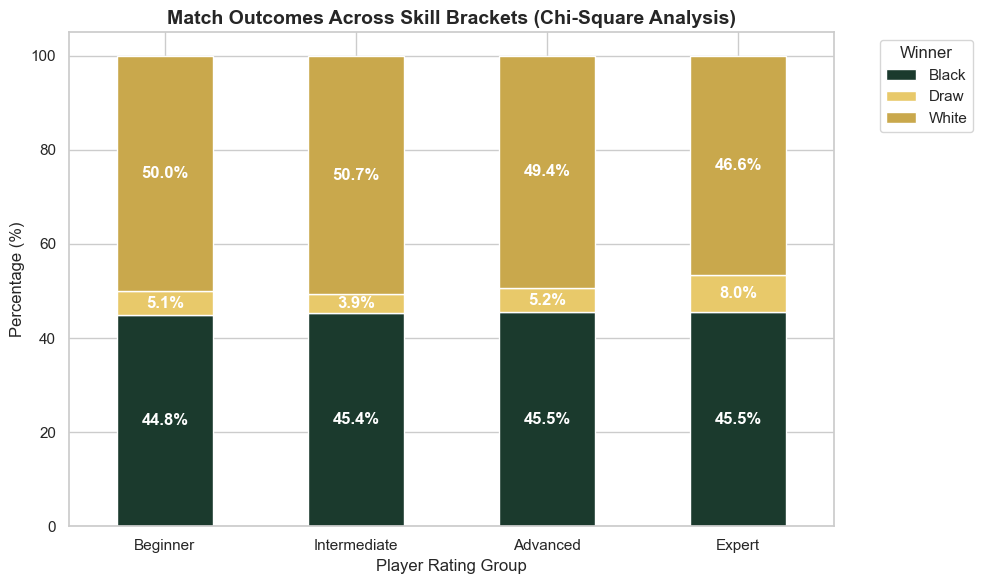

In [68]:
# Prepare the data as percentages for each category to ensure a visually fair comparison.
contingency_pct = pd.crosstab(df['rating_tier'], df['winner'], normalize='index') * 100

# Graph
ax = contingency_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1B3A2D', '#E8C96A', '#C9A84C'])
plt.title('Match Outcomes Across Skill Brackets (Chi-Square Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Player Rating Group', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Winner', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adding the percentage as text inside the columns
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    ax.annotate(f'{height:.1f}%', (x + width/2, y + height/2), ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(
    '../output/charts/chi_square_outcomes.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Figure 3: Stacked bar chart illustrating match outcomes across player skill tiers. Although the Chi-Square test reveals a statistically significant relationship (p < 0.001), the visually balanced segments reflect the very low Cramér's V effect size (0.038), indicating a negligible practical impact.

## AQ5 — 95% confidence intervals for rated vs. unrated turns (parametric + bootstrap)

In [39]:
def confidence_interval(data: pd.Series, confidence: float = 0.95) -> tuple:
    """
    Calculate parametric confidence interval.
    """
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)
    h = se * t_dist.ppf((1 + confidence) / 2., n - 1)
    return mean - h, mean + h

def bootstrap_ci(data: np.ndarray, n_boot: int = 1000, confidence: float = 0.95) -> np.ndarray:
    """
    Calculate bootstrap confidence interval.
    """
    rng = np.random.default_rng(42)
    means = [rng.choice(data, len(data), replace=True).mean() for _ in range(n_boot)]
    a = (1 - confidence) / 2
    return np.percentile(means, [a * 100, (1 - a) * 100])

# تشغيل الدوال على البيانات
for label, group in [('Rated', df[df['rated'] == True]['turns']),
                     ('Unrated', df[df['rated'] == False]['turns'])]:
    lo, hi = confidence_interval(group)
    lo_b, hi_b = bootstrap_ci(group.values)
    print(f"{label}: n={len(group)}, mean={group.mean():.1f}")
    print(f"  Parametric 95% CI: ({lo:.1f}, {hi:.1f})")
    print(f"  Bootstrap  95% CI: ({lo_b:.1f}, {hi_b:.1f})")

Rated: n=16155, mean=62.0
  Parametric 95% CI: (61.4, 62.5)
  Bootstrap  95% CI: (61.4, 62.5)
Unrated: n=3903, mean=54.3
  Parametric 95% CI: (53.3, 55.3)
  Bootstrap  95% CI: (53.2, 55.3)


### AQ5: 95% Confidence Intervals (Parametric vs. Bootstrap)

**Conclusion:** We are 95% confident that Rated games are significantly longer on average than Unrated games. Both parametric and non-parametric bootstrap methodologies yield identical intervals, confirming that our large sample size makes the estimates highly robust against non-normality.

**Evidence:**
* **Rated Games (n = 16,155):** Mean = 62.0 turns. Both Parametric and Bootstrap 95% CIs are identical at $[61.4, 62.5]$ turns.
* **Unrated Games (n = 3,903):** Mean = 54.3 turns. The Parametric CI is $[53.3, 55.3]$ turns, and the Bootstrap CI is $[53.2, 55.3]$ turns.
* **Statistical Inference:** Because the 95% confidence intervals for Rated and Unrated games do not overlap at all, we have definitive inferential proof that Rated games last longer. This aligns with the behavioral theory that players take matches more seriously and fight longer when their official rank/points are on the line.

## Figure 4: 95% Confidence Intervals (AQ5)

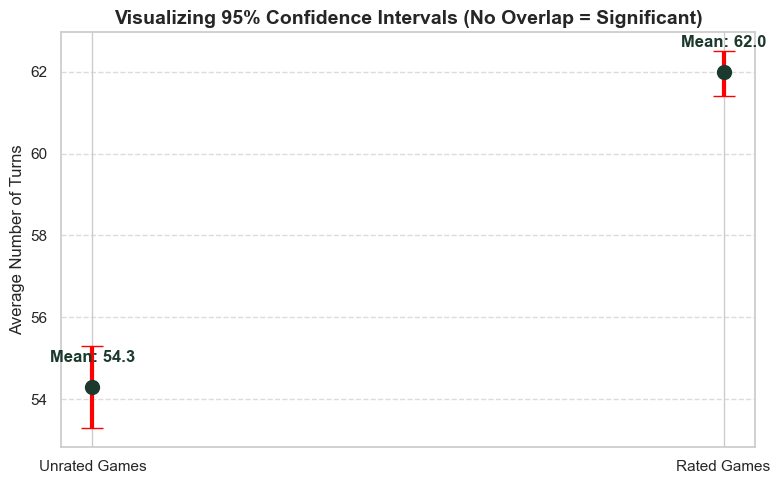

In [62]:
plt.figure(figsize=(8, 5))

# Plotting metrics based on the computed confidence intervals (Parametric & Bootstrap)
match_types = ['Unrated Games', 'Rated Games']
observed_means = [54.3, 62.0]

# Define the lower and upper error margins extracted from the CI outputs
error_margins = [[54.3 - 53.3, 62.0 - 61.4],  # Lower bounds
                 [55.3 - 54.3, 62.5 - 62.0]]  # Upper bounds

# Draw the error bars representing the 95% Confidence Interval
plt.errorbar(match_types, observed_means, yerr=error_margins, fmt='o', color='#1B3A2D', 
             ecolor='red', elinewidth=3, capsize=8, markersize=10, label='95% Confidence Interval')

plt.title('Visualizing 95% Confidence Intervals (No Overlap = Significant)', fontsize=14, fontweight='bold')
plt.ylabel('Average Number of Turns', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Label the exact mean value on top of each data point
for i, mean in enumerate(observed_means):
    plt.text(i, mean + 0.6, f"Mean: {mean:.1f}", ha='center', fontweight='bold', color='#1B3A2D')

plt.tight_layout()
plt.savefig(
    '../output/charts/confidence_intervals.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Figure 4: Visual representation of 95% confidence intervals for the average number of turns. The complete absence of overlap between Rated and Unrated error bars provides definitive inferential evidence that Rated games last significantly longer on average.